In [1]:
import torch
import matplotlib.pyplot as plt
from gradnet import GradNet, fit
from gradnet.utils import positions_to_distance_matrix, plot_graph, random_seed, _shortest_path
import networkx as nx
import numpy as np

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Updates:   0%|          | 0/10000 [00:00<?, ?it/s]


  | Name | Type    | Params | Mode 
-----------------------------------------
0 | gn   | GradNet | 10.0 K | train
-----------------------------------------
10.0 K    Trainable params
0         Non-trainable params
10.0 K    Total params
0.040     Total estimated model params size (MB)
`Trainer.fit` stopped: `max_epochs=10000` reached.


False None


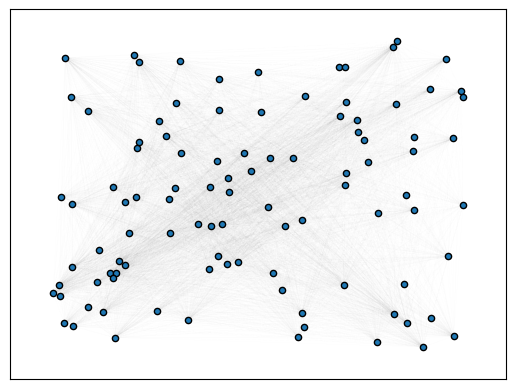

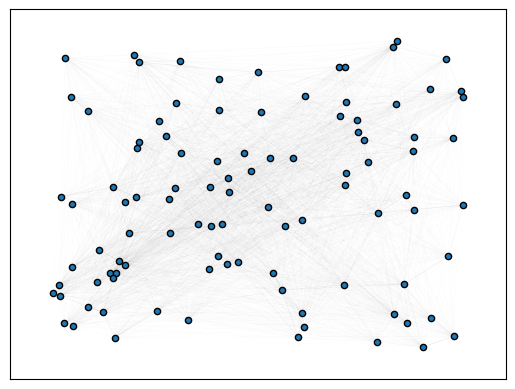

In [25]:
N = 100
L = 10.0
budget_per_node = 1

seed = 0
random_seed(seed)

positions = torch.rand(N, 2) * L  # random coordinates in an LxL square
cost_matrix = positions_to_distance_matrix(positions)  # all-to-all distances

pos_dict = {idx: pos.tolist() for idx, pos in enumerate(positions)}
draw_kwargs = {
    "pos": pos_dict,
    "with_labels": False,
    "node_size": 20
}

updates = 10000
lr = 0.1

gn = GradNet(
    num_nodes=N,
    budget=budget_per_node * N,
    cost_matrix=cost_matrix,
    rand_init_weights=0
)

plot_graph(gn, layout="networkx", draw_kwargs=draw_kwargs)

def loss_fn(gn):
    A = gn()  # get the adjacency matrix
    L = torch.diag(A.sum(dim=1)) - A  # compute the graph Laplacian
    eigs = torch.linalg.eigvalsh(L)  # compute the eigenvalues
    l2 = eigs[1]  # second smallest eigenvalue (algebraic connectivity)
    # loss is (1-λ₂), so minimizing it maximizes λ₂. 
    return 1-l2  # return loss, and also λ₂ as a metric

fit(
    gn=gn,
    loss_fn=loss_fn,
    num_updates=updates,
    optim_kwargs={"lr": lr},
    enable_checkpointing=False,
    accelerator="cpu",
    verbose=True,
)

plot_graph(gn, layout="networkx", draw_kwargs=draw_kwargs)